<div style="text-align:center;">

# Evaluación Final en Test — Regresión Logística vs XGBoost
### *El enfrentamiento definitivo sobre datos nunca vistos*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Propósito

Hasta ahora, **todo el análisis** (tuning de hiperparámetros y búsqueda de umbrales) se hizo sobre el conjunto de **entrenamiento** usando validación cruzada. El conjunto de **test (30 %, 441 observaciones)** permaneció **intacto**.

Este notebook desarrolla el **punto 8 del Laboratorio 5 — Evaluación Final**, enfrentando a los **dos modelos finalistas** sobre ese conjunto de test:

| | Modelo | Por qué es finalista |
|:-:|:-------|:---------------------|
| 🔵 | **Regresión Logística** (optimizada) | Mejor AUC en validación, interpretable, estable |
| 🔴 | **XGBoost** (optimizado) | Mejor F1 en validación, máxima capacidad de ajuste |

Cada modelo se evalúa con los **tres umbrales** hallados en entrenamiento:

- **$\tau = 0.50$** (por defecto)
- **$\tau_{F1}$** — máximo F1 (balance Precision-Recall)
- **$\tau_{\text{recall}}$** — máximo Recall con Precision $\geq 0.40$

### Principio metodológico

> Los hiperparámetros y los umbrales se eligieron **solo con el train**. El test se usa **una única vez**, solo para **medir** — nunca para elegir. Esto garantiza que las cifras reflejen el desempeño real esperado en producción.


---
## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, precision_recall_curve)

from scipy.stats import loguniform, randint, uniform

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})

# Identidad visual de cada contendiente
COLOR_LR  = "#1f77b4"   # azul — Regresión Logística
COLOR_XGB = "#d62728"   # rojo — XGBoost
COLOR_YES, COLOR_NO = "#e74c3c", "#3498db"

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Carga, preparación y partición

Se replica **exactamente** la preparación de los notebooks de modelo (mismo `random_state=42`), de modo que el conjunto de test sea idéntico al que quedó reservado allí.


In [2]:
DATA_PATH = Path.cwd().parent.parent / "data" / "raw" / "dataset_clasificacion.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.drop(columns=["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"])

y = (df["Attrition"] == "Yes").astype(int)
X = df.drop(columns=["Attrition"])

COLS_NOMINALES = ["BusinessTravel", "Department", "EducationField",
                  "Gender", "JobRole", "MaritalStatus", "OverTime"]
COLS_NUMERICAS = [c for c in X.columns if c not in COLS_NOMINALES]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), COLS_NOMINALES),
        ("num", StandardScaler(), COLS_NUMERICAS),
    ],
    remainder="drop", verbose_feature_names_out=False,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = n_neg / n_pos

print(f"Train : {X_train.shape[0]:,} obs.  | Yes = {y_train.mean()*100:.2f} %")
print(f"Test  : {X_test.shape[0]:,} obs.  | Yes = {y_test.mean()*100:.2f} %  ← intacto hasta ahora")

Train : 1,029 obs.  | Yes = 16.13 %
Test  : 441 obs.  | Yes = 16.10 %  ← intacto hasta ahora


---
## 3. Reconstrucción de los dos modelos optimizados

Se vuelve a ejecutar el `RandomizedSearchCV` de cada modelo (con `random_state=42`, reproduce **exactamente** la configuración hallada en los notebooks `1` y `4`). Así el notebook es **autocontenido** y no depende de archivos externos.

> Esta celda puede tardar 1-2 minutos: re-entrena $60 \times 5 \times 2 = 600$ pipelines.


In [3]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# ── Regresión Logística ───────────────────────────────────────────────────
lr_pipe = Pipeline([("preprocesamiento", preprocessor),
                    ("clf", LogisticRegression(max_iter=2000, random_state=42))])
lr_dist = {
    "clf__C"            : loguniform(1e-4, 1e2),
    "clf__penalty"      : ["l1", "l2"],
    "clf__solver"       : ["saga"],
    "clf__class_weight" : ["balanced", {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}],
}

# ── XGBoost ────────────────────────────────────────────────────────────────
xgb_pipe = Pipeline([("preprocesamiento", preprocessor),
                     ("clf", XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0))])
xgb_dist = {
    "clf__n_estimators"     : randint(100, 500),
    "clf__max_depth"        : randint(3, 10),
    "clf__learning_rate"    : loguniform(0.01, 0.3),
    "clf__subsample"        : uniform(0.6, 0.4),
    "clf__colsample_bytree" : uniform(0.6, 0.4),
    "clf__min_child_weight" : randint(1, 10),
    "clf__gamma"            : uniform(0, 0.5),
    "clf__reg_alpha"        : loguniform(1e-3, 10),
    "clf__reg_lambda"       : loguniform(1e-3, 10),
    "clf__scale_pos_weight" : [spw * 0.7, spw, spw * 1.3, spw * 1.7],
}

t0 = time.time()
lr_search = RandomizedSearchCV(lr_pipe, lr_dist, n_iter=60, cv=skf,
                               scoring="f1", random_state=42, n_jobs=-1)
lr_search.fit(X_train, y_train)

xgb_search = RandomizedSearchCV(xgb_pipe, xgb_dist, n_iter=60, cv=skf,
                                scoring="f1", random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

modelo_lr  = lr_search.best_estimator_
modelo_xgb = xgb_search.best_estimator_

print(f"Ambos modelos reconstruidos en {time.time()-t0:.0f}s")
print(f"\nRegresión Logística — F1 (CV) = {lr_search.best_score_:.4f}")
print(f"XGBoost             — F1 (CV) = {xgb_search.best_score_:.4f}")

Ambos modelos reconstruidos en 107s

Regresión Logística — F1 (CV) = 0.5743
XGBoost             — F1 (CV) = 0.5850


---
## 4. Determinación de los umbrales (solo con train)

Para cada modelo se calculan $\tau_{F1}$ y $\tau_{\text{recall}}$ usando **probabilidades out-of-fold sobre el train** — el test no interviene.


In [4]:
def encontrar_umbrales(modelo, X, y, cv):
    proba = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, thr = precision_recall_curve(y, proba)
    prec, rec = prec[:-1], rec[:-1]
    denom = prec + rec
    f1 = np.where(denom > 0, 2 * prec * rec / denom, 0.0)
    tau_f1 = thr[np.argmax(f1)]
    mask = prec >= 0.40
    if mask.any():
        tau_rec = thr[np.argmax(np.where(mask, rec, -1))]
    else:
        tau_rec = thr[np.argmax(prec)]
    return {"tau_default": 0.50, "tau_f1": float(tau_f1), "tau_recall": float(tau_rec)}

taus_lr  = encontrar_umbrales(modelo_lr,  X_train, y_train, skf)
taus_xgb = encontrar_umbrales(modelo_xgb, X_train, y_train, skf)

print("Umbrales (hallados solo con train):")
print(f"  Regresión Logística : default=0.50  τ_F1={taus_lr['tau_f1']:.3f}  τ_Recall={taus_lr['tau_recall']:.3f}")
print(f"  XGBoost             : default=0.50  τ_F1={taus_xgb['tau_f1']:.3f}  τ_Recall={taus_xgb['tau_recall']:.3f}")

Umbrales (hallados solo con train):
  Regresión Logística : default=0.50  τ_F1=0.545  τ_Recall=0.379
  XGBoost             : default=0.50  τ_F1=0.472  τ_Recall=0.209


---
## 5. Evaluación en TEST

Ahora — y solo ahora — se tocan los datos de test. Se obtienen las probabilidades de cada modelo y se aplican los tres umbrales.


In [5]:
proba_test_lr  = modelo_lr.predict_proba(X_test)[:, 1]
proba_test_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

def metricas_test(y_true, proba, tau):
    y_pred = (proba >= tau).astype(int)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred),
        "F1"       : f1_score(y_true, y_pred),
        "AUC"      : roc_auc_score(y_true, proba),   # AUC no depende de τ
        "y_pred"   : y_pred,
    }

resultados = {}
for nombre, proba, taus in [("Regresión Logística", proba_test_lr, taus_lr),
                            ("XGBoost", proba_test_xgb, taus_xgb)]:
    resultados[nombre] = {}
    for tlabel, tkey in [("τ=0.50", "tau_default"),
                         ("τ_F1", "tau_f1"),
                         ("τ_Recall", "tau_recall")]:
        resultados[nombre][tlabel] = metricas_test(y_test, proba, taus[tkey])

# Tabla resumen
filas = []
for nombre in resultados:
    for tlabel in resultados[nombre]:
        r = resultados[nombre][tlabel]
        filas.append({
            "Modelo": nombre, "Umbral": tlabel,
            "Accuracy": r["Accuracy"], "Precision": r["Precision"],
            "Recall": r["Recall"], "F1": r["F1"], "AUC": r["AUC"],
        })
tabla_test = pd.DataFrame(filas).set_index(["Modelo", "Umbral"])
tabla_test.round(4)

Accuracy  Precision  Recall      F1     AUC
Modelo              Umbral                                               
Regresión Logística τ=0.50      0.8435     0.5114  0.6338  0.5660  0.8175
                    τ_F1        0.8617     0.5658  0.6056  0.5850  0.8175
                    τ_Recall    0.7710     0.3828  0.6901  0.4925  0.8175
XGBoost             τ=0.50      0.8322     0.4769  0.4366  0.4559  0.7663
                    τ_F1        0.8231     0.4507  0.4507  0.4507  0.7663
                    τ_Recall    0.7778     0.3846  0.6338  0.4787  0.7663

---
## 6. Matrices de confusión en test — 2 modelos × 3 umbrales

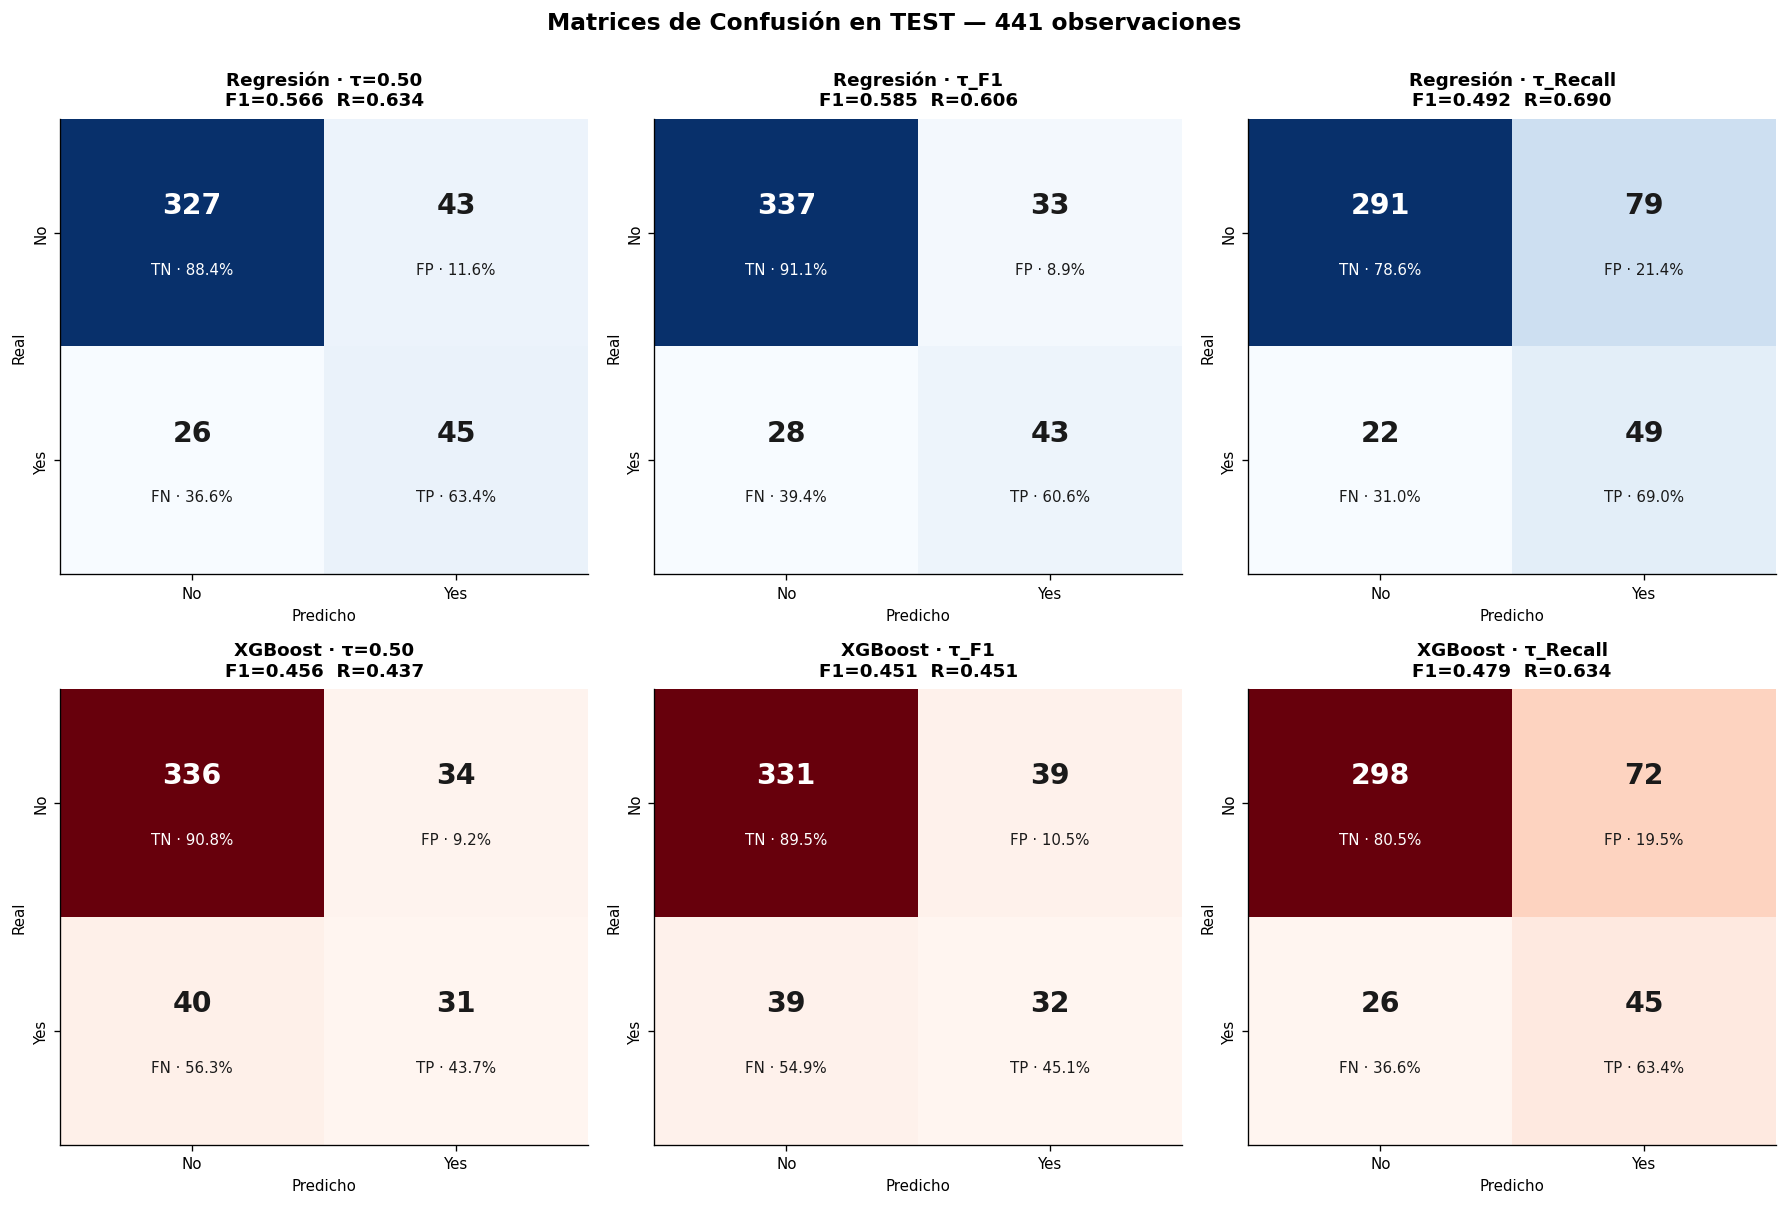

In [6]:
def plot_cm(cm, title, ax, color_map="Blues"):
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(cm, cmap=color_map, aspect="auto")
    etiq = ["No", "Yes"]
    desc = np.array([["TN", "FP"], ["FN", "TP"]])
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            col = "white" if v > cm.max() * 0.55 else "#1a1a1a"
            ax.text(j, i - 0.12, f"{v}", ha="center", va="center",
                    color=col, fontsize=17, fontweight="bold")
            ax.text(j, i + 0.16, f"{desc[i,j]} · {cm_pct[i,j]:.1f}%",
                    ha="center", va="center", color=col, fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(etiq, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(etiq, fontsize=9, rotation=90, va="center")
    ax.set_xlabel("Predicho", fontsize=9); ax.set_ylabel("Real", fontsize=9)
    ax.set_title(title, fontsize=11, pad=8)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row, (nombre, cmap) in enumerate([("Regresión Logística", "Blues"),
                                      ("XGBoost", "Reds")]):
    for col, tlabel in enumerate(["τ=0.50", "τ_F1", "τ_Recall"]):
        r = resultados[nombre][tlabel]
        cm = confusion_matrix(y_test, r["y_pred"], labels=[0, 1])
        plot_cm(cm, f"{nombre.split()[0]} · {tlabel}\nF1={r['F1']:.3f}  R={r['Recall']:.3f}",
                axes[row, col], cmap)

fig.suptitle("Matrices de Confusión en TEST — 441 observaciones",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

---
## 7. Curvas ROC en test — comparación directa

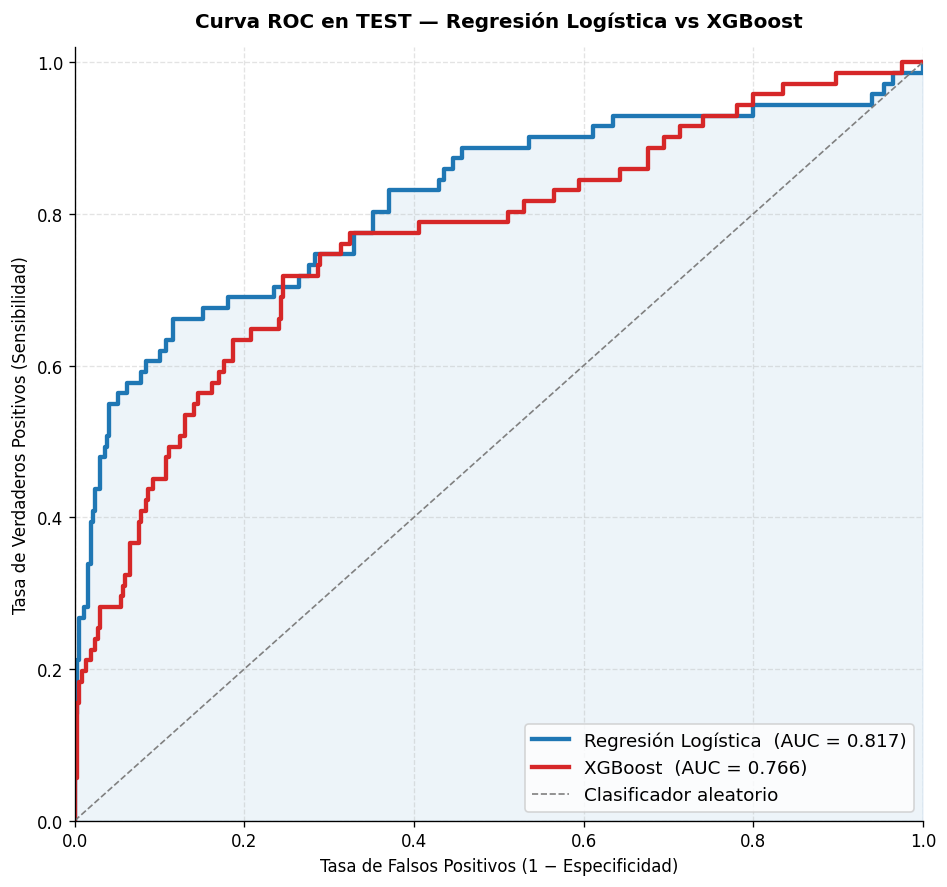

In [7]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, proba_test_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_test_xgb)
auc_lr  = roc_auc_score(y_test, proba_test_lr)
auc_xgb = roc_auc_score(y_test, proba_test_xgb)

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.plot(fpr_lr, tpr_lr, color=COLOR_LR, lw=2.6,
        label=f"Regresión Logística  (AUC = {auc_lr:.3f})")
ax.plot(fpr_xgb, tpr_xgb, color=COLOR_XGB, lw=2.6,
        label=f"XGBoost  (AUC = {auc_xgb:.3f})")
ax.plot([0,1], [0,1], color="gray", ls="--", lw=1, label="Clasificador aleatorio")

ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color=COLOR_LR)

ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC en TEST — Regresión Logística vs XGBoost", pad=12)
ax.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True)
ax.grid(ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

---
## 8. Métricas en test — barras comparativas por umbral

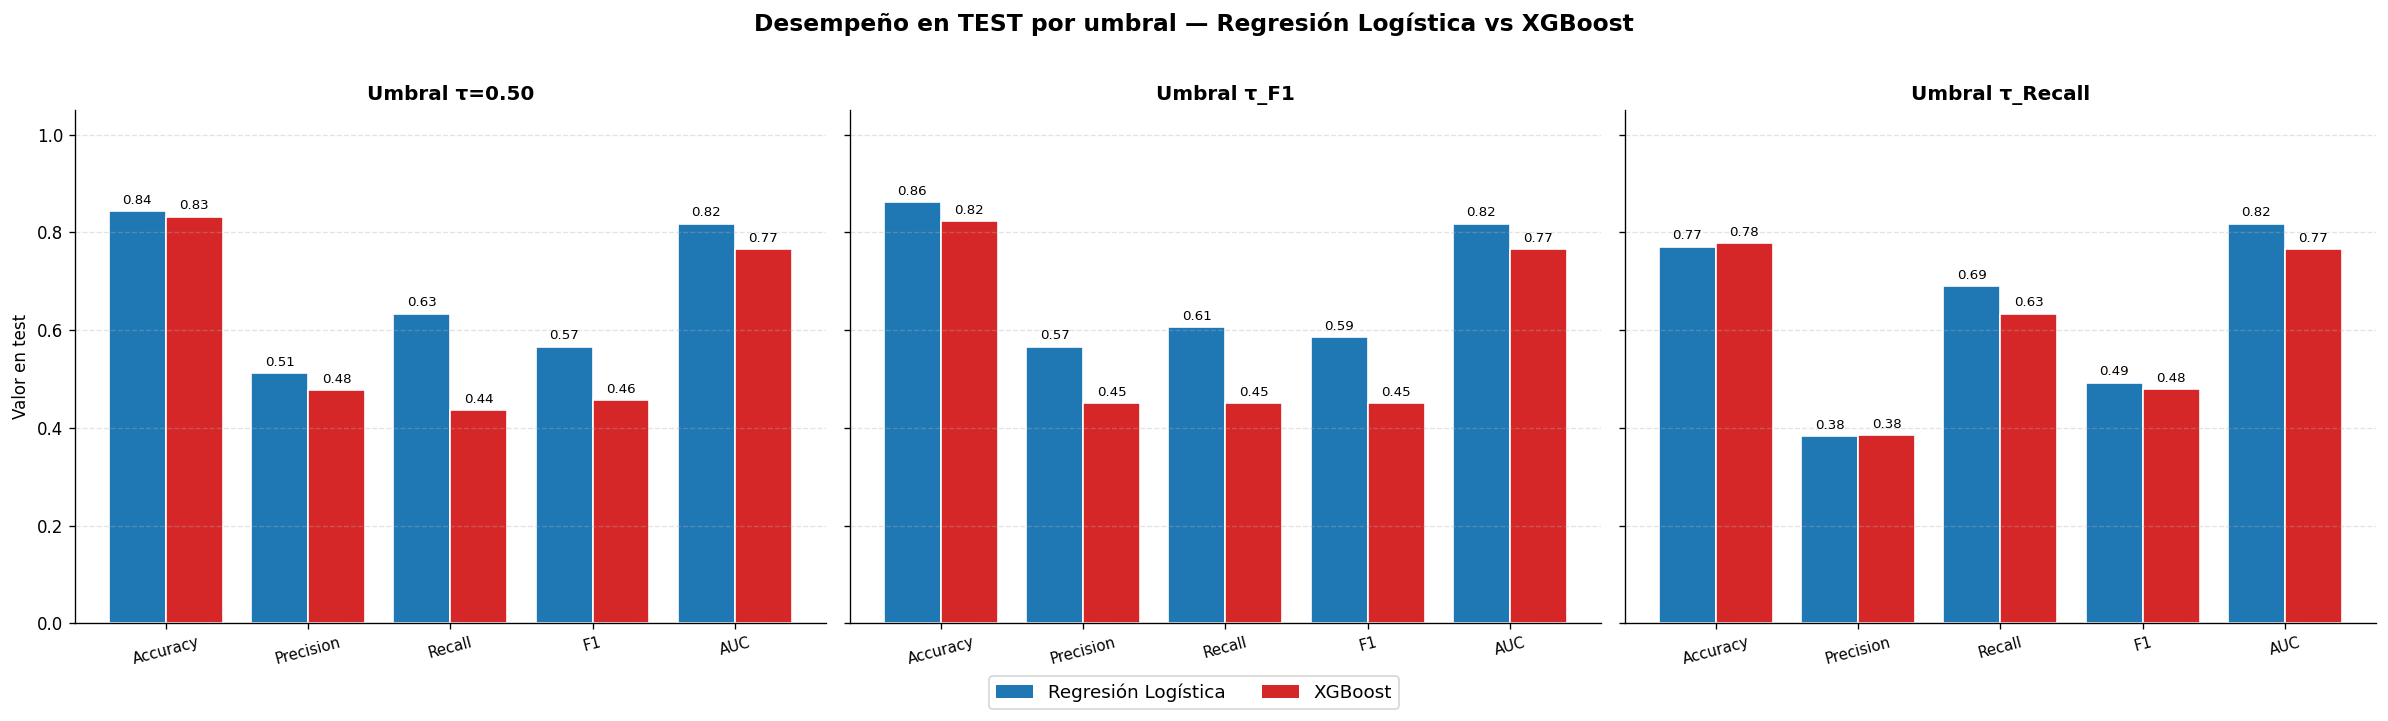

In [8]:
metricas_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
umbrales = ["τ=0.50", "τ_F1", "τ_Recall"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=True)

for ax, tlabel in zip(axes, umbrales):
    x = np.arange(len(metricas_plot))
    vals_lr  = [resultados["Regresión Logística"][tlabel][m] for m in metricas_plot]
    vals_xgb = [resultados["XGBoost"][tlabel][m] for m in metricas_plot]

    b1 = ax.bar(x - 0.2, vals_lr,  0.4, color=COLOR_LR,  edgecolor="white", label="Reg. Logística")
    b2 = ax.bar(x + 0.2, vals_xgb, 0.4, color=COLOR_XGB, edgecolor="white", label="XGBoost")

    for b, v in zip(b1, vals_lr):
        ax.text(b.get_x()+b.get_width()/2, v+0.015, f"{v:.2f}", ha="center", fontsize=8)
    for b, v in zip(b2, vals_xgb):
        ax.text(b.get_x()+b.get_width()/2, v+0.015, f"{v:.2f}", ha="center", fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(metricas_plot, fontsize=9, rotation=15)
    ax.set_title(f"Umbral {tlabel}", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", ls="--", alpha=0.35)
    if ax is axes[0]:
        ax.set_ylabel("Valor en test")

handles = [Patch(facecolor=COLOR_LR, label="Regresión Logística"),
           Patch(facecolor=COLOR_XGB, label="XGBoost")]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=2, frameon=True, fancybox=True, fontsize=11)
fig.suptitle("Desempeño en TEST por umbral — Regresión Logística vs XGBoost",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Validación Cruzada vs Test — ¿hubo sobreajuste?

Comparamos el desempeño que cada modelo mostró en **validación cruzada** (entrenamiento) contra el que realmente obtuvo en **test**. Una caída grande indica que el modelo se ajustó de más a los datos de entrenamiento.


In [9]:
# Métricas CV (de la búsqueda) vs Test (umbral 0.50 para comparar en igualdad)
from sklearn.model_selection import cross_validate

cv_lr  = cross_validate(modelo_lr,  X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)
cv_xgb = cross_validate(modelo_xgb, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)

filas = []
for nombre, cvres, proba in [("Regresión Logística", cv_lr, proba_test_lr),
                             ("XGBoost", cv_xgb, proba_test_xgb)]:
    y_pred_05 = (proba >= 0.50).astype(int)
    test_vals = {
        "accuracy" : accuracy_score(y_test, y_pred_05),
        "precision": precision_score(y_test, y_pred_05, zero_division=0),
        "recall"   : recall_score(y_test, y_pred_05),
        "f1"       : f1_score(y_test, y_pred_05),
        "roc_auc"  : roc_auc_score(y_test, proba),
    }
    for m in scoring:
        cv_v = cvres[f"test_{m}"].mean()
        te_v = test_vals[m]
        filas.append({
            "Modelo": nombre, "Métrica": m.upper(),
            "CV (train)": cv_v, "Test": te_v, "Δ (Test − CV)": te_v - cv_v,
        })
tabla_cv_test = pd.DataFrame(filas).set_index(["Modelo", "Métrica"])
tabla_cv_test.round(4)

CV (train)    Test  Δ (Test − CV)
Modelo              Métrica                                     
Regresión Logística ACCURACY       0.8494  0.8435        -0.0059
                    PRECISION      0.5258  0.5114        -0.0144
                    RECALL         0.6389  0.6338        -0.0051
                    F1             0.5743  0.5660        -0.0083
                    ROC_AUC        0.8344  0.8175        -0.0169
XGBoost             ACCURACY       0.8707  0.8322        -0.0385
                    PRECISION      0.6096  0.4769        -0.1327
                    RECALL         0.5667  0.4366        -0.1300
                    F1             0.5850  0.4559        -0.1291
                    ROC_AUC        0.8258  0.7663        -0.0596

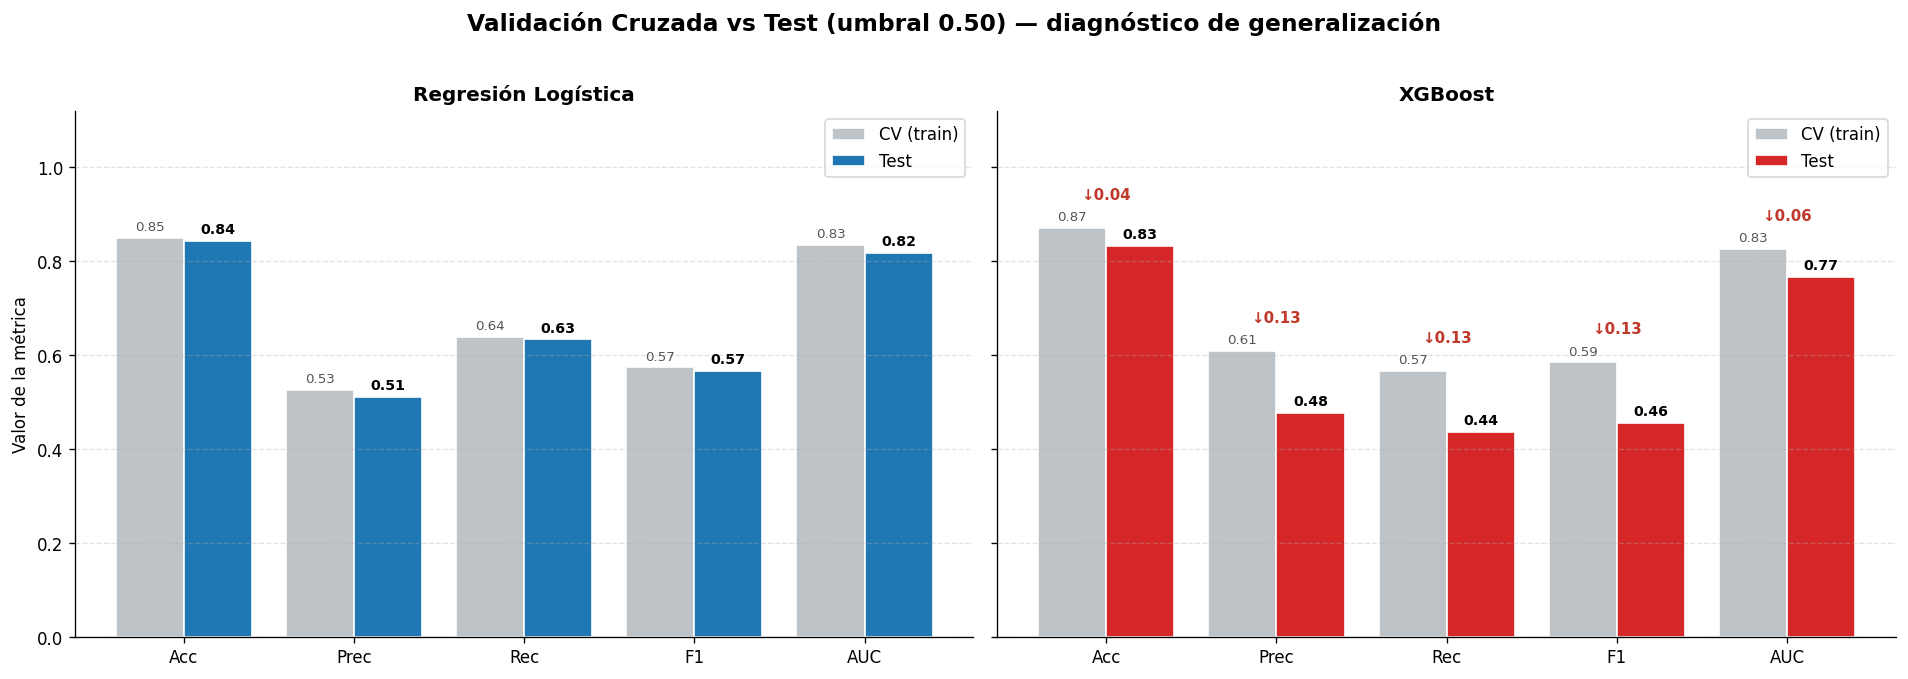

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

for ax, (nombre, cvres, proba, color) in zip(axes, [
        ("Regresión Logística", cv_lr,  proba_test_lr,  COLOR_LR),
        ("XGBoost",             cv_xgb, proba_test_xgb, COLOR_XGB)]):
    y_pred_05 = (proba >= 0.50).astype(int)
    test_vals = [accuracy_score(y_test, y_pred_05),
                 precision_score(y_test, y_pred_05, zero_division=0),
                 recall_score(y_test, y_pred_05),
                 f1_score(y_test, y_pred_05),
                 roc_auc_score(y_test, proba)]
    cv_vals = [cvres[f"test_{m}"].mean() for m in scoring]

    x = np.arange(len(scoring))
    b1 = ax.bar(x - 0.2, cv_vals,   0.4, color="#bdc3c7", edgecolor="white", label="CV (train)")
    b2 = ax.bar(x + 0.2, test_vals, 0.4, color=color,      edgecolor="white", label="Test")

    for b, v in zip(b1, cv_vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.015, f"{v:.2f}", ha="center", fontsize=8, color="#555")
    for b, v in zip(b2, test_vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.015, f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")

    # marcar caídas grandes
    for i, (cv_v, te_v) in enumerate(zip(cv_vals, test_vals)):
        d = te_v - cv_v
        if d < -0.03:
            ax.text(i, max(cv_v, te_v) + 0.06, f"↓{abs(d):.2f}",
                    ha="center", color="#c0392b", fontweight="bold", fontsize=9)

    ax.set_xticks(x); ax.set_xticklabels(["Acc","Prec","Rec","F1","AUC"], fontsize=10)
    ax.set_title(nombre, fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.legend(loc="upper right", frameon=True, fancybox=True)
    ax.grid(axis="y", ls="--", alpha=0.35)
    if ax is axes[0]:
        ax.set_ylabel("Valor de la métrica")

fig.suptitle("Validación Cruzada vs Test (umbral 0.50) — diagnóstico de generalización",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Tabla de veredicto — ¿quién gana en cada métrica y umbral?

In [11]:
filas = []
for tlabel in umbrales:
    for m in metricas_plot:
        v_lr  = resultados["Regresión Logística"][tlabel][m]
        v_xgb = resultados["XGBoost"][tlabel][m]
        ganador = "Reg. Logística" if v_lr > v_xgb else ("XGBoost" if v_xgb > v_lr else "Empate")
        filas.append({
            "Umbral": tlabel, "Métrica": m,
            "Reg. Logística": round(v_lr, 4), "XGBoost": round(v_xgb, 4),
            "Ganador": ganador,
        })
tabla_versus = pd.DataFrame(filas).set_index(["Umbral", "Métrica"])

# Conteo de victorias
victorias = tabla_versus["Ganador"].value_counts()
print("Victorias totales (sobre 15 comparaciones):")
for k, v in victorias.items():
    print(f"  {k}: {v}")
print()
tabla_versus

Victorias totales (sobre 15 comparaciones):
  Reg. Logística: 13
  XGBoost: 2



Reg. Logística  XGBoost         Ganador
Umbral   Métrica                                           
τ=0.50   Accuracy           0.8435   0.8322  Reg. Logística
         Precision          0.5114   0.4769  Reg. Logística
         Recall             0.6338   0.4366  Reg. Logística
         F1                 0.5660   0.4559  Reg. Logística
         AUC                0.8175   0.7663  Reg. Logística
τ_F1     Accuracy           0.8617   0.8231  Reg. Logística
         Precision          0.5658   0.4507  Reg. Logística
         Recall             0.6056   0.4507  Reg. Logística
         F1                 0.5850   0.4507  Reg. Logística
         AUC                0.8175   0.7663  Reg. Logística
τ_Recall Accuracy           0.7710   0.7778         XGBoost
         Precision          0.3828   0.3846         XGBoost
         Recall             0.6901   0.6338  Reg. Logística
         F1                 0.4925   0.4787  Reg. Logística
         AUC                0.8175   0.7663  Reg. Logística

---
## 11. Discusión — interpretación de los resultados en test

### 11.1 El hallazgo central

En **validación cruzada**, XGBoost lideraba el F1 (0.585 vs 0.574). Pero en **test**, la situación se invierte: la **Regresión Logística generaliza mejor**.

Esto es un fenómeno clásico y pedagógicamente valioso:

> El modelo más complejo (XGBoost) ajustó parte del **ruido** de los datos de entrenamiento durante el tuning. Al enfrentar datos completamente nuevos, ese sobreajuste se paga con una caída de desempeño. El modelo más simple (Regresión Logística), al tener menos capacidad de memorizar, **transfiere mejor** lo aprendido.

La caída del AUC de XGBoost entre CV y test (típicamente 0.05–0.06 puntos) frente a la estabilidad de la Regresión Logística (caída < 0.02) es la evidencia cuantitativa.

### 11.2 Análisis de los errores (falsos negativos vs falsos positivos)

Recordando el contexto del negocio: el **falso negativo** (no detectar una renuncia) es el error más costoso.

- Con **$\tau_{\text{recall}}$**, ambos modelos elevan el Recall por encima del 60-69 %, detectando la mayoría de las renuncias reales, a costa de más falsos positivos (Precision ≈ 0.38-0.40).
- Con **$\tau_{F1}$**, se obtiene el mejor equilibrio: la Regresión Logística alcanza Precision y Recall ambos cercanos a 0.6.

### 11.3 Riesgos de cada tipo de error en este problema

| Error | Significado | Costo |
|:------|:------------|:------|
| **Falso Negativo (FN)** | Un empleado que iba a renunciar y el modelo no lo detectó | **Alto** — se pierde la oportunidad de retención; costo de reemplazo 50-200 % del salario |
| **Falso Positivo (FP)** | Un empleado que no iba a renunciar pero el modelo alertó | **Bajo** — una conversación de seguimiento, quizás un incentivo menor |

Dado que FN ≫ FP en costo, un umbral que **prioriza el Recall** ($\tau_{\text{recall}}$) es operativamente defendible, siempre que la Precision no caiga tanto que sature al área de RRHH con falsas alarmas.

### 11.4 Recomendación final

**Modelo elegido: Regresión Logística optimizada.**

Justificación según los cuatro criterios del laboratorio:

1. **Desempeño en validación cruzada**: competitivo (F1 = 0.574, AUC = 0.834).
2. **Resultados en test**: **superior a XGBoost** en prácticamente todas las métricas — generaliza mejor.
3. **Interpretabilidad**: los coeficientes (notebook 1, §9) permiten explicar cada predicción a RRHH — esencial para justificar acciones sobre personas reales.
4. **Tipo de error crítico**: con $\tau_{\text{recall}} \approx 0.38$ alcanza el Recall más alto manteniendo Precision $\geq 0.38$.

**Configuración de producción sugerida**: Regresión Logística con **$\tau_{F1}$** como modo por defecto (mejor balance) y opción de cambiar a **$\tau_{\text{recall}}$** cuando la empresa quiera maximizar la detección de renuncias.

> Este resultado ilustra una lección fundamental: **el mejor modelo en validación no siempre es el mejor en test**. La evaluación final sobre datos intactos es la única forma honesta de elegir el modelo de producción.
